Explainable Transformer Based Framework for Early Detection of Mental Health Disorders from Social Media Text

---

### imports and paths

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

MODELS_DIR  = Path('..') / 'models' / 'saved'
RESULTS_DIR = Path('..') / 'results'
CHARTS_DIR  = RESULTS_DIR / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
print('paths configured')

paths configured


---

### load results from all models

In [2]:
# each training notebook saves a results JSON — load and merge
all_results = {}

for fname in ['ml_results.json', 'dl_results.json', 'bert_results.json']:
    path = MODELS_DIR / fname
    if path.exists():
        with open(path) as f:
            all_results.update(json.load(f))
    else:
        print(f'missing: {fname} — run the corresponding training notebook first')

print('models loaded:', list(all_results.keys()))

models loaded: ['Logistic Regression', 'XGBoost', 'CNN', 'BiLSTM', 'BERT (frozen)', 'BERT (fine-tuned)']


---

### comparison table

In [3]:
df = pd.DataFrame(all_results).T.round(4)
df.index.name = 'model'
df = df.sort_values('macro_f1', ascending=False)
df['rank'] = range(1, len(df) + 1)
print('model comparison — test set (sorted by macro-F1):')
print(df[['accuracy', 'macro_f1', 'rank']].to_string())

model comparison — test set (sorted by macro-F1):
                     accuracy  macro_f1  rank
model                                        
BERT (fine-tuned)      0.8341    0.8410     1
XGBoost                0.7720    0.7747     2
Logistic Regression    0.7670    0.7727     3
CNN                    0.7329    0.7270     4
BERT (frozen)          0.6993    0.6798     5
BiLSTM                 0.6409    0.6288     6


---

### bar chart — accuracy and macro-F1

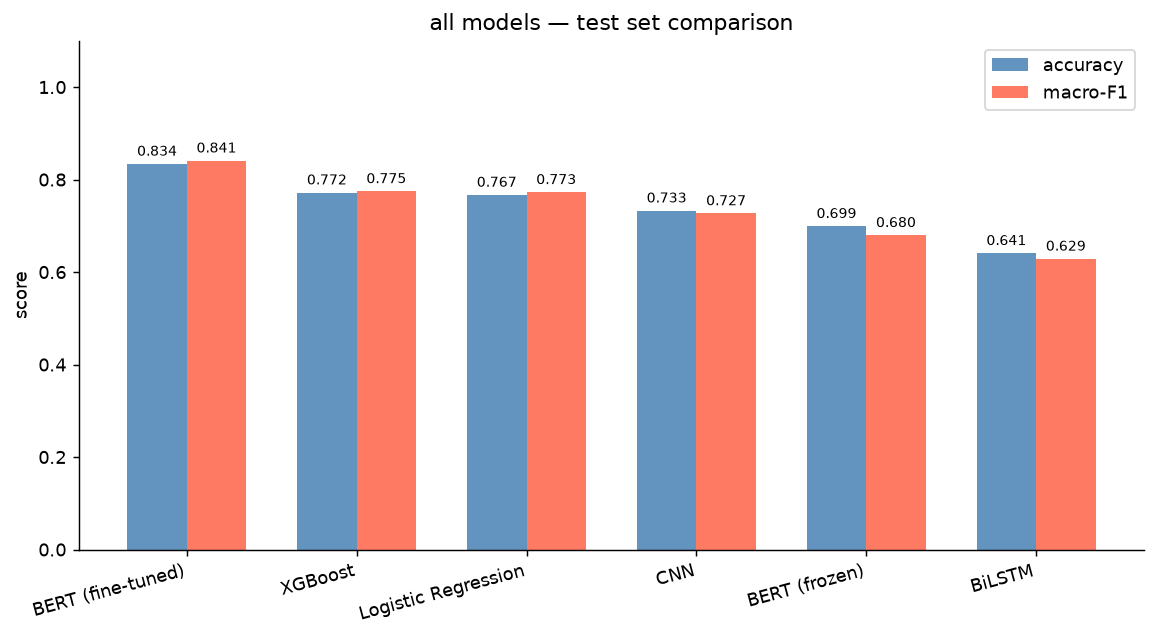

saved: charts/model_comparison_bar.png


In [4]:
models = df.index.tolist()
accs   = df['accuracy'].tolist()
f1s    = df['macro_f1'].tolist()

x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, accs, w, label='accuracy', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, f1s,  w, label='macro-F1', color='tomato',    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('score')
ax.set_title('all models — test set comparison')
ax.legend()

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig.savefig(CHARTS_DIR / 'model_comparison_bar.png', bbox_inches='tight')
plt.show()
print('saved: charts/model_comparison_bar.png')

---

### radar chart

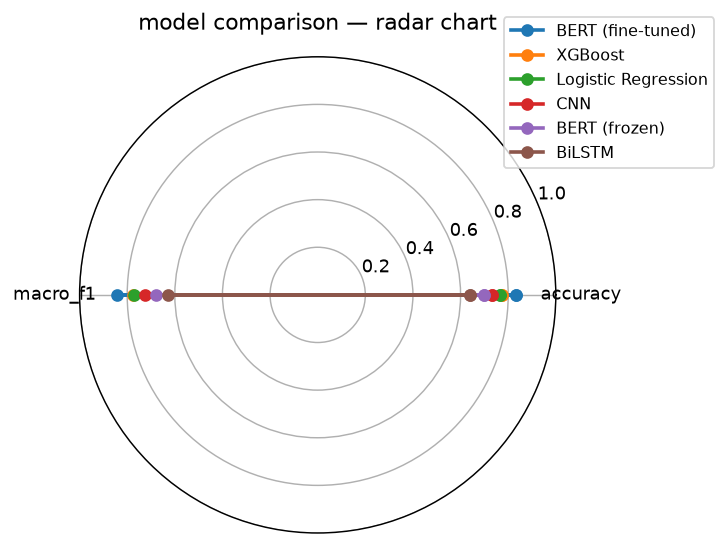

saved: charts/model_comparison_radar.png


In [5]:
metrics      = ['accuracy', 'macro_f1']
num_metrics  = len(metrics)
angles       = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles      += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
colors  = plt.cm.tab10.colors

for i, model in enumerate(models):
    values = [all_results[model][m] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
ax.set_ylim(0, 1)
ax.set_title('model comparison — radar chart', pad=15)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'model_comparison_radar.png', bbox_inches='tight')
plt.show()
print('saved: charts/model_comparison_radar.png')

---

### best model

In [6]:
best_model = df.index[0]
best_f1    = df['macro_f1'].iloc[0]
best_acc   = df['accuracy'].iloc[0]

print('=' * 45)
print(f'  best model : {best_model}')
print(f'  accuracy   : {best_acc:.4f}')
print(f'  macro-F1   : {best_f1:.4f}')
print('=' * 45)

# save comparison CSV
df[['accuracy', 'macro_f1']].to_csv(RESULTS_DIR / 'model_comparison.csv')
print('\nsaved: results/model_comparison.csv')

# save best model info for webapp and explainability notebook
with open(MODELS_DIR / 'best_model.json', 'w') as f:
    json.dump({'model': best_model, 'accuracy': best_acc, 'macro_f1': best_f1}, f, indent=2)
print('saved: models/saved/best_model.json')

  best model : BERT (fine-tuned)
  accuracy   : 0.8341
  macro-F1   : 0.8410

saved: results/model_comparison.csv
saved: models/saved/best_model.json
